# What is Reaction SMARTS?
Reaction SMARTS is a way to define a chemical reaction as a transformation rule.
Instead of drawing a reaction manually, you tell RDKit:
"Whenever you find this functional group, transform it into this new functional group."

Reaction SMARTS is a rule-based language used to describe how one chemical structure is transformed into another.

# Example

Suppose we have an alcohol
CH3OH

Recation SMARTS can say:

Alcohol

↓

Replace OH

↓

Cl

Output: CH3Cl   RDKit performs this transformation automatically.

# Applications

# 1. Virtual Synthesis


Instead of synthesizing molecules in the laboratory first,
scientists create them virtually.

Reactants

↓

Reaction SMARTS

↓

Virtual Products

# 2. Combinatorial Chemistry

Suppose you have

50 amines and 100 acids.

Reaction SMARTS automatically generates

50 × 100

↓

5000 Amides
This is called reaction enumeration.

# 3. Library Generation

Instead of creating molecules one by one,
generate thousands automatically.
# 4. Medicinal Chemistry
    
Suppose you want to answer:
"What happens if I convert every alcohol into an ester?"
One reaction rule can generate all those analogues.

# Example

Suppose we have ethanol:
CH3CH2OH

we want to convert it into chloroethane:
CH3CH2Cl

CH3CH2OH

      │
      │  Reaction SMARTS
      ▼
      
CH3CH2Cl


In [3]:
# Import Libraries

from rdkit import Chem
from rdkit.Chem import AllChem, Draw

In [5]:
# Create the Reaction

reaction = AllChem.ReactionFromSmarts(
    "[C:1][OH:2]>>[C:1]Cl"
)

# left side [C:1][OH:2] (Reactant) meaning: carbib--OH
# find a carbon attached to an OH group
# right side [C:1]Cl ( Product ) meaning: carbon--Cl
# Replace the OH with chlorine

In [6]:
# Create the Reactant

ethanol = Chem.MolFromSmiles("CCO")

In [7]:
# Run the Reaction 

products = reaction.RunReactants((ethanol,))

[11:40:48] mapped atoms in the reactants were not mapped in the products.
  unmapped numbers are: 2 


In [8]:
# Get the Product 

product = products[0][0]

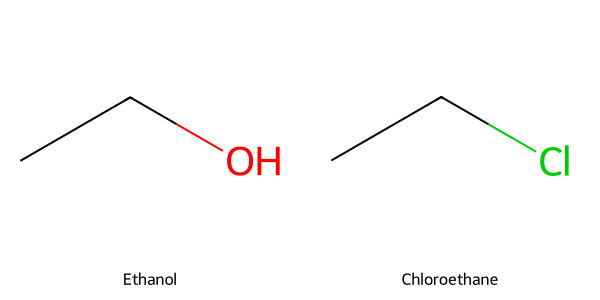

In [9]:
# Visualize 

Draw.MolsToGridImage(
    [ethanol, product],
    legends=["Ethanol", "Chloroethane"],
    molsPerRow=2,
    subImgSize=(300,300)
)

## Interpretation

A Reaction SMARTS rule was used to convert ethanol into chloroethane.

The rule searched for a carbon atom attached to a hydroxyl group (OH) and replaced the hydroxyl group with a chlorine atom while preserving the rest of the molecular structure.

This demonstrates how Reaction SMARTS performs rule-based chemical transformations without manually redrawing the product molecule.

RDKit doesn't know chemistry in the sense of reaction mechanisms. It simply follows the transformation rule you provide.